# Acoustic Scattering for head shaped obstacle

This notebook provide acoustic field simulation for scattering field using an head shaped obstacle.

Due to computing constrained with provided trained networks for single direction of incident wave.


## Google Colab setup

In [63]:
# Export the modules
#!git clone https://github.com/Dankradino/Acoustic-Scattering-PINN.git

import os
os.getcwd()
#os.chdir('/content/Acoustic-Scattering-PINN/')
os.chdir('/home/dankrad/Desktop/code/Acoustic-Scattering-PINN/')
os.getcwd()

'/home/dankrad/Desktop/code/Acoustic-Scattering-PINN'

In [64]:
#!pip install trimesh pysofaconventions==0.1.5 rtree  # Sufficient for testing models

## Import and configuration setup

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from model import init_model_from_conf
from utils import load_hrtf_config, generate_grid
import matplotlib.pyplot as plt
from Dataloader import load_hrtf
import trimesh


torch.manual_seed(30)

In [66]:
# Normalization of a sonicom head
#subject_id = 'P0002'
#mesh_path   = f'SONICOM/{subject_id}/3DSCAN/{subject_id}_wtt_prepd.stl'
#normalize_path = f'SONICOM/{subject_id}/3DSCAN/{subject_id}_normalized_with_ear.stl'
#mesh = trimesh.load_mesh(mesh_path, process=False)

# Conversion of mm to m
#mesh.vertices /= 1000.0  # now in meters

#Normalization
#scale = mesh.bounding_box.extents.max()
#scale = 0.75 * 2.0 / scale # Let some space outside of the head for the sound field
#print('Scale',scale)
#mesh.apply_scale(scale)
#print('Max of mesh vertices', np.max(mesh.vertices))
#mesh.export(normalize_path)

In [67]:
# ========== CONFIGURATION ==========
# Choose incident wave direction: 'x' or 'y'
DIRECTION = 'y'  # <-- Change this to 'x' or 'y'

subject_id = 'P0002'
model_name = 'rff'

# Paths derived from direction choice
dir_with_ear = f'checkpoints/hrtf/p2_{DIRECTION}_with_ear'
dir_no_ear   = f'checkpoints/hrtf/p2_{DIRECTION}_no_ear'

config_with_ear_path = f'{dir_with_ear}/config.yaml'
config_no_ear_path   = f'{dir_no_ear}/config.yaml'

model_with_ear_path = f'{dir_with_ear}/{model_name}.pth'
model_no_ear_path   = f'{dir_no_ear}/{model_name}.pth'

mesh_with_ear_path = f'SONICOM/{subject_id}/3DSCAN/{subject_id}_normalized_with_ear.stl'
mesh_no_ear_path   = f'SONICOM/{subject_id}/3DSCAN/{subject_id}_normalized_no_ear.stl'

sofa_path = f'SONICOM/{subject_id}/SYNTHETIC_HRTF/HRIR_SONICOM_44100.sofa'

loss_fn = nn.MSELoss()

# Load both configs
config_ear, DTYPE = load_hrtf_config(config_with_ear_path)
config_no_ear, _  = load_hrtf_config(config_no_ear_path)
device = config_ear['device']
config_ear['model']    = model_name
config_no_ear['model'] = model_name

print(f"=== Direction: {DIRECTION} ===")
print(f"With-ear config direction : {config_ear['direction'].squeeze()}")
print(f"No-ear config direction   : {config_no_ear['direction'].squeeze()}")
print(f"With-ear scale: {config_ear['scale']:.6f}, No-ear scale: {config_no_ear['scale']:.6f}")

=== Direction: y ===
With-ear config direction : tensor([0., 1., 0.], device='cuda:0')
No-ear config direction   : tensor([0., 1., 0.], device='cuda:0')
With-ear scale: 5.749200, No-ear scale: 5.475182


## Loading HRTF meshes (with and without ears)

Vertices corresponding to ears:
Vertex 1: [-0.06464245  0.36936876 -0.12925814]
Vertex 2: [-0.06935535 -0.38831091 -0.12595482]
First frequencies available : [0.0 150.0 300.0 450.0 600.0 750.0 900.0 1050.0 1200.0 1350.0 1500.0
 1650.0 1800.0 1950.0 2100.0]


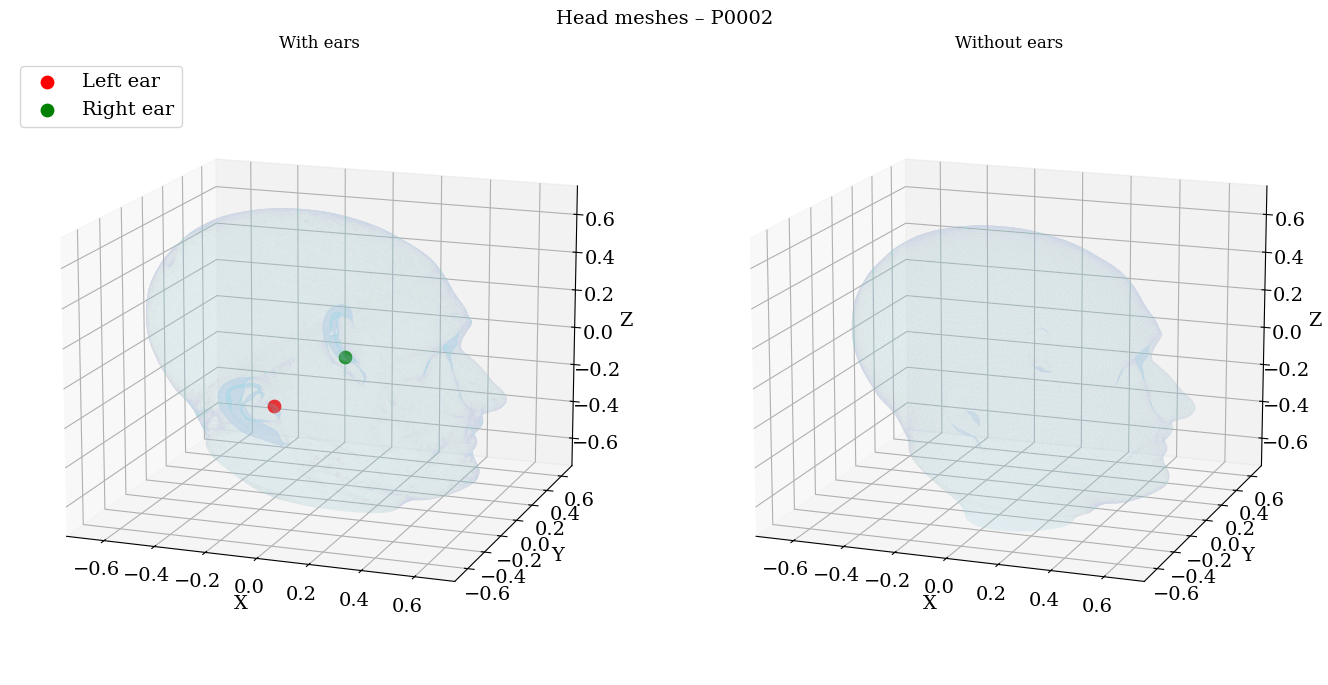

In [68]:
# Load head meshes
mesh_ear    = trimesh.load(mesh_with_ear_path, process=False)
mesh_no_ear = trimesh.load(mesh_no_ear_path, process=False)

# Load SOFA for with-ear mesh (identifies ear canal entrances)
boundary_ear_verts = mesh_ear.vertices
sofa = load_hrtf(sofa_path, boundary_ear_verts, DTYPE, device)
idx_ear = sofa["ear_idx"].cpu().numpy()

# --- Visualise both meshes side by side ---
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig, axes = plt.subplots(1, 2, figsize=(14, 7), subplot_kw={'projection': '3d'})
for ax, (mesh_viz, title) in zip(axes,
        [(mesh_ear, 'With ears'), (mesh_no_ear, 'Without ears')]):
    verts = mesh_viz.vertices[mesh_viz.faces]
    center = mesh_viz.vertices.mean(axis=0)
    scale_v = mesh_viz.vertices.max(axis=0) - mesh_viz.vertices.min(axis=0)
    half = scale_v.max() / 2

    poly = Poly3DCollection(verts, alpha=0.15, facecolor='lightblue', edgecolor='none')
    ax.add_collection3d(poly)

    # Mark ear canals on the with-ear mesh
    if title == 'With ears':
        ear_pts = boundary_ear_verts[idx_ear]
        left_idx  = np.argmin(ear_pts[:, 1])
        right_idx = np.argmax(ear_pts[:, 1])
        ax.scatter(*ear_pts[left_idx],  c='red',   s=80, depthshade=False, zorder=10, label='Left ear')
        ax.scatter(*ear_pts[right_idx], c='green', s=80, depthshade=False, zorder=10, label='Right ear')
        ax.legend(loc='upper left')

    ax.set_xlim(center[0] - half, center[0] + half)
    ax.set_ylim(center[1] - half, center[1] + half)
    ax.set_zlim(center[2] - half, center[2] + half)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(title)
    ax.view_init(elev=15, azim=-70)

fig.suptitle(f'Head meshes – {subject_id}', fontsize=14)
plt.tight_layout()
plt.show()

## Loading models (with-ear and no-ear)

In [69]:
# --- Load with-ear model ---
model_with_ear = init_model_from_conf(config_ear).to(device)
model_with_ear.load_state_dict(torch.load(model_with_ear_path))
model_with_ear.eval()
print('With-ear model loaded!')

# --- Load no-ear model ---
model_without_ear = init_model_from_conf(config_no_ear).to(device)
model_without_ear.load_state_dict(torch.load(model_no_ear_path))
model_without_ear.eval()
print('No-ear model loaded!')

With-ear model loaded!
No-ear model loaded!


In [70]:
def evaluate_model_on_grid(model, config, mesh, grid, res, device):
    """Evaluate a model on a 3D grid, returning scattered, incident, and total fields."""
    grid_np = grid.cpu().numpy()

    # Interior mask via trimesh
    inside = mesh.contains(grid_np)
    inside_3d = inside.reshape(res, res, res)
    outside_t = torch.tensor(~inside, device=device)

    # Scattered field (model output)
    with torch.no_grad():
        p_s = torch.zeros(grid_np.shape[0], 2, device=device)
        p_s[outside_t] = model(grid[outside_t])

    # Incident wave
    freq  = float(config['frequency'])
    scale = float(config.get('scale', 1.0))
    p0    = float(config.get('p0', 1.0))
    k     = 2 * np.pi * freq / config['celerity']
    mode  = config.get('mode', 'plane')

    if mode == 'source':
        x_source = config['source'].reshape(1, 3).float()
        r = torch.linalg.norm(grid.float() - x_source, dim=1) / scale
        r = torch.clamp(r, min=1e-6)
        u_inc_c = p0 * torch.exp(torch.tensor(1j * k, dtype=torch.complex64) * r) / (4 * np.pi * r)
    else:
        direction = config['direction'].squeeze().float()
        r_proj = (grid.float() @ direction) / scale
        u_inc_c = torch.exp(torch.tensor(1j * k, dtype=torch.complex64) * r_proj)

    p_inc = torch.stack([u_inc_c.real, u_inc_c.imag], dim=1)
    p_inc[~outside_t] = 0.0

    p_total = p_s + p_inc
    return p_s, p_inc, p_total, inside_3d

# --- Common grid ---
res = 64
L = config_ear['L']
grid = generate_grid(L, res, 3, device=device)

# --- Evaluate both models ---
print("Evaluating with-ear model...")
p_s_ear, p_inc_ear, p_total_ear, inside_3d_ear = evaluate_model_on_grid(
    model_with_ear, config_ear, mesh_ear, grid, res, device)

print("Evaluating no-ear model...")
p_s_noear, p_inc_noear, p_total_noear, inside_3d_noear = evaluate_model_on_grid(
    model_without_ear, config_no_ear, mesh_no_ear, grid, res, device)

print("Done!")

Evaluating with-ear model...
Evaluating no-ear model...
Done!


In [71]:
def compute_xy_magnitude(p, res, inside_3d, axis='z'):
    """Return masked scattered-field magnitude at the XY mid-plane (z=0)."""
    z_mid = res // 2
    if axis == 'x':
        shape = (z_mid, slice(None), slice(None))
    elif axis == 'y':
        shape = (slice(None), z_mid, slice(None))
    elif axis == 'z':
        shape = (slice(None), slice(None), z_mid)

    p_np = p.cpu().numpy()
    p_r = p_np[:, 0].reshape(res, res, res)[shape]
    p_i = p_np[:, 1].reshape(res, res, res)[shape]
    mag = np.sqrt(p_r**2 + p_i**2)
    return np.ma.masked_where(inside_3d[shape], mag)


def build_arrow_coords(config, L):
    """Build arrow annotation dicts based on the incident wave direction.

    Each 2-D slice shows two of the three physical axes:
        z-slice → horizontal=y, vertical=x
        y-slice → horizontal=z, vertical=x
        x-slice → horizontal=z, vertical=y

    The arrow is placed at the domain edge, pointing inward along the
    projected direction.  Returns None for slices where the direction is
    perpendicular (no in-plane component).
    """
    dir_vec = config['direction'].cpu().numpy().squeeze()
    slice_to_axes = {'z': (0, 1), 'y': (2, 1), 'x': (2, 0)}

    coords = {}
    for axe, (h_idx, v_idx) in slice_to_axes.items():
        dh, dv = dir_vec[h_idx], dir_vec[v_idx]
        norm = np.sqrt(dh**2 + dv**2)
        if norm < 1e-6:
            coords[axe] = None          # perpendicular to slice
        else:
            dh_n, dv_n = dh / norm, dv / norm
            tail_h, tail_v = dh_n * L * 0.95, dv_n * L * 0.95
            tip_h,  tip_v  = dh_n * L * 0.65, dv_n * L * 0.65
            coords[axe] = dict(xy=(tip_h, tip_v), xytext=(tail_h, tail_v))
    return coords


def plot_field_comparison(field_pairs, arrow_coords, res, L, suptitle):
    """Plot 3-slice comparison (x/y/z) for a list of (name, field, mask) tuples."""
    axes_labels = ['x', 'y', 'z']
    n_cols = len(field_pairs)

    plt.rcParams.update({'text.usetex': False, 'font.family': 'serif',
                         'font.size': 14, 'axes.titlesize': 12, 'axes.labelsize': 14})
    cmap = 'rainbow'
    fig, axs = plt.subplots(3, n_cols, figsize=(6 * n_cols, 10), constrained_layout=False)
    plt.subplots_adjust(right=0.88, hspace=0.3, wspace=0.1)

    im_grid = {}
    for i, axe in enumerate(axes_labels):
        for j, (pname, pf, mask_3d) in enumerate(field_pairs):
            u = compute_xy_magnitude(pf, res, mask_3d, axe)
            im = axs[i][j].imshow(u, extent=[-L, L, -L, L],
                                   origin='lower', cmap=cmap,
                                   vmin=u.min(), vmax=u.max())
            im_grid[(i, j)] = im

            if arrow_coords[axe] is not None:
                axs[i][j].annotate('', arrowprops=dict(arrowstyle='->', color='red', lw=2),
                                   **arrow_coords[axe])
            axs[i][j].set_title(f'{pname} – {axe.upper()} slice')
            axs[i][j].set_xticks([])
            axs[i][j].set_yticks([])

    for i in range(3):
        cbar_ax = fig.add_axes([0.90, 0.68 - i * 0.31, 0.02, 0.25])
        fig.colorbar(im_grid[(i, n_cols - 1)], cax=cbar_ax)

    fig.suptitle(suptitle, fontsize=16, fontweight='bold', y=1.02)
    plt.show()

# Build direction-aware arrows
arrow_coords = build_arrow_coords(config_ear, L)
print("Arrow coords per slice:", {k: ('arrow' if v else 'none') for k, v in arrow_coords.items()})

Arrow coords per slice: {'z': 'arrow', 'y': 'arrow', 'x': 'none'}


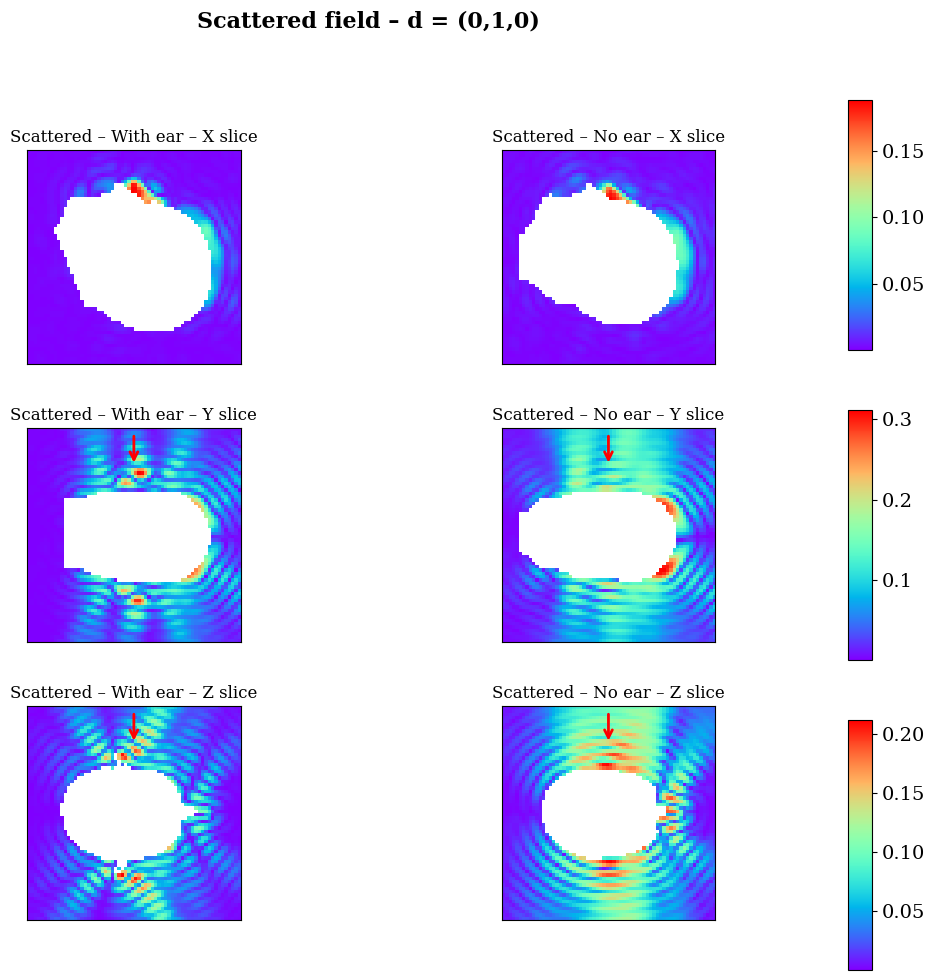

In [72]:
# --- Scattered field comparison ---
dir_vec = config_ear['direction'].cpu().numpy().squeeze()
plot_field_comparison(
    field_pairs=[
        ('Scattered – With ear',  p_s_ear,   inside_3d_ear),
        ('Scattered – No ear',    p_s_noear, inside_3d_noear),
    ],
    arrow_coords=arrow_coords,
    res=res, L=L,
    suptitle=f'Scattered field – d = ({dir_vec[0]:.0f},{dir_vec[1]:.0f},{dir_vec[2]:.0f})',
)

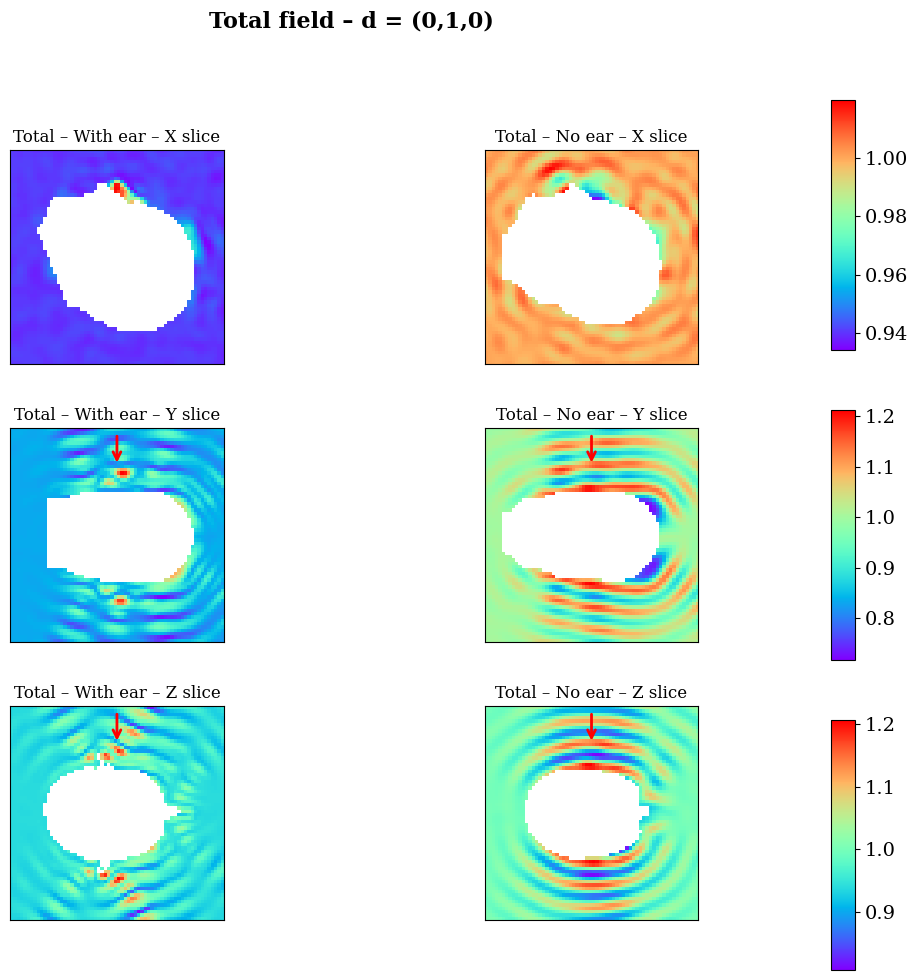

In [73]:
# --- Total field comparison ---
plot_field_comparison(
    field_pairs=[
        ('Total – With ear',  p_total_ear,   inside_3d_ear),
        ('Total – No ear',    p_total_noear, inside_3d_noear),
    ],
    arrow_coords=arrow_coords,
    res=res, L=L,
    suptitle=f'Total field – d = ({dir_vec[0]:.0f},{dir_vec[1]:.0f},{dir_vec[2]:.0f})',
)

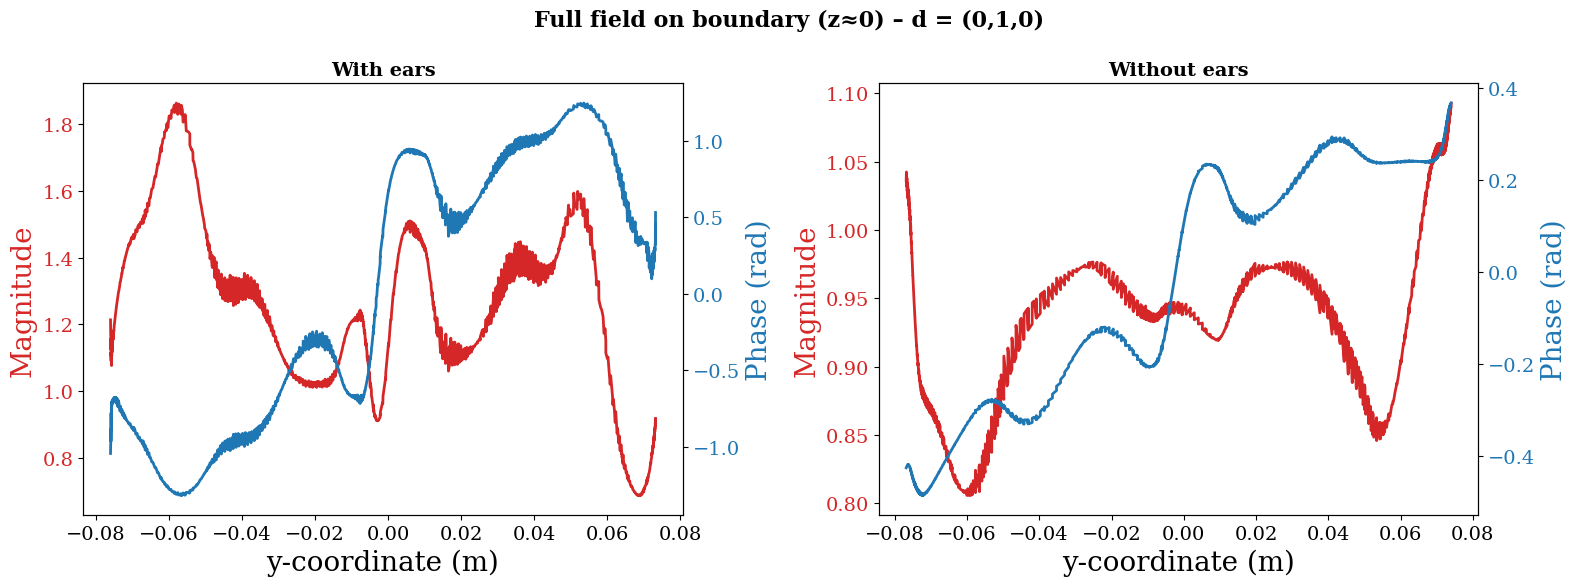

In [74]:
# --- Boundary-line comparison: with ear vs no ear ---
# Extract boundary points near z=0 from each mesh

def extract_boundary_ring(mesh, device, z_tol=0.01):
    """Extract and sort boundary vertices near z=0 with positive x."""
    b = torch.tensor(mesh.vertices, device=device)
    idx = (torch.abs(b[:, 2]) < z_tol) & (b[:, 0] > 0)
    b_filtered = b[idx]
    order = torch.argsort(b_filtered[:, 1])
    return b_filtered[order]

def inc_wave(coords, config):
    """Compute incident wave field at given coordinates."""
    freq  = float(config['frequency'])
    scale = float(config.get('scale', 1.0))
    p0    = float(config.get('p0', 1.0))
    k     = 2 * np.pi * freq / config['celerity']
    mode  = config.get('mode', 'plane')

    if mode == 'source':
        x_source = config['source'].reshape(1, 3).float()
        r = torch.linalg.norm(coords.float() - x_source, dim=1) / scale
        r = torch.clamp(r, min=1e-6)
        g = p0 * torch.exp(1j * k * r) / (4 * np.pi * r)
    else:
        direction = config['direction'].squeeze().float()
        r = (coords.float() @ direction) / scale
        g = torch.exp(1j * k * r)
    return torch.stack((g.real, g.imag), dim=-1)

def model_total_field(model, config, coords):
    """Evaluate total field = scattered + incident on boundary coords."""
    coords_t = coords.clone().to(device).float()
    with torch.no_grad():
        p_sc  = model(coords_t)
        p_inc = inc_wave(coords_t, config)
        p_tot = p_sc + p_inc
    return p_tot.cpu().numpy()

def mag_phase_decomp(model, config, boundary):
    p = model_total_field(model, config, boundary)
    p_complex = p[:, 0] + 1j * p[:, 1]
    mag = np.abs(p_complex)
    phase = np.unwrap(np.angle(p_complex))
    return mag, phase

# Extract boundary rings
bnd_ear   = extract_boundary_ring(mesh_ear, device)
bnd_noear = extract_boundary_ring(mesh_no_ear, device)

# Compute mag/phase for both models
mag_ear,   phase_ear   = mag_phase_decomp(model_with_ear,    config_ear,    bnd_ear)
mag_noear, phase_noear = mag_phase_decomp(model_without_ear, config_no_ear, bnd_noear)

# --- Plot ---
plt.rcParams.update({'text.usetex': False, 'font.family': 'serif',
                     'font.size': 14, 'axes.titlesize': 24, 'axes.labelsize': 20})
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(16, 6))

y_ear   = (bnd_ear[:, 1]   / config_ear['scale']).cpu().numpy()
y_noear = (bnd_noear[:, 1] / config_no_ear['scale']).cpu().numpy()

# Left: With ear
ax1.set_xlabel('y-coordinate (m)')
ax1.set_ylabel('Magnitude', color='tab:red')
ax1.plot(y_ear, mag_ear, color='tab:red', lw=2, label='Magnitude')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax2 = ax1.twinx()
ax2.set_ylabel('Phase (rad)', color='tab:blue')
ax2.plot(y_ear, phase_ear, color='tab:blue', lw=2, label='Phase')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_title('With ears', fontsize=14, fontweight='bold')

# Right: No ear
ax3.set_xlabel('y-coordinate (m)')
ax3.set_ylabel('Magnitude', color='tab:red')
ax3.plot(y_noear, mag_noear, color='tab:red', lw=2, label='Magnitude')
ax3.tick_params(axis='y', labelcolor='tab:red')
ax4 = ax3.twinx()
ax4.set_ylabel('Phase (rad)', color='tab:blue')
ax4.plot(y_noear, phase_noear, color='tab:blue', lw=2, label='Phase')
ax4.tick_params(axis='y', labelcolor='tab:blue')
ax3.set_title('Without ears', fontsize=14, fontweight='bold')

dir_vec = config_ear['direction'].cpu().numpy().squeeze()
fig.suptitle(f'Full field on boundary (z≈0) – d = ({dir_vec[0]:.0f},{dir_vec[1]:.0f},{dir_vec[2]:.0f})',
             fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()